In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Load Data and split

In [2]:
df = pd.read_csv('diabetes.csv')

X = df.drop('Outcome', axis=1)  
y = df['Outcome']              

### Train-test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scaling

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

### Training Model with best k parameter

In [5]:
k_values = range(1, 21,2)
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

best_k = k_values[np.argmax(scores)]
print(f"Best K: {best_k}")

Best K: 19


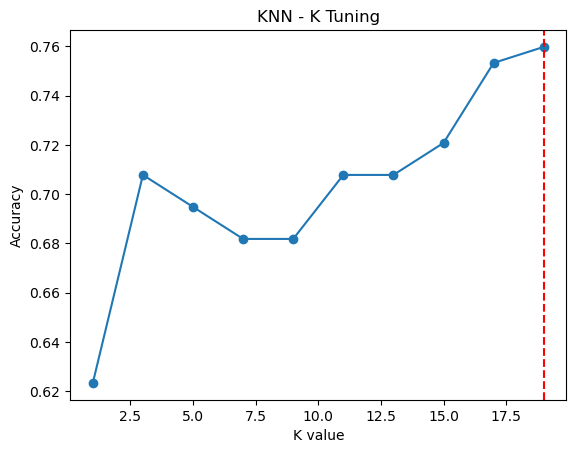

In [6]:
plt.plot(k_values, scores, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN - K Tuning")
plt.axvline(x=best_k, color='r', linestyle='--')
plt.show()

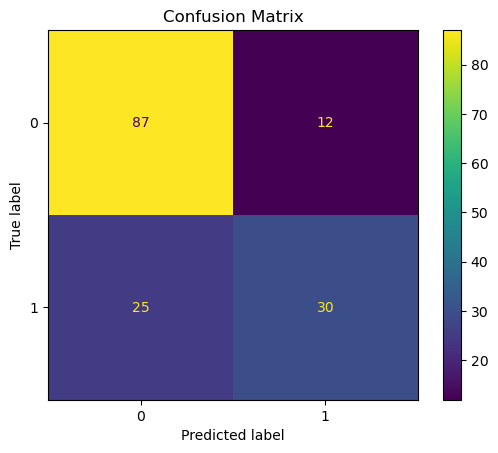

Final Accuracy: 0.7597402597402597


In [7]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

print("Final Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
# Visaula